In [1]:
# Install dependencies
!pip install -q "gymnasium[mujoco]>=1.0.0" "gymnasium-robotics>=1.3.0"
!pip install -q torch wandb imageio
!pip install -q mujoco

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 30.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from gymnasium_robotics import mamujoco_v1
import matplotlib.pyplot as plt
import wandb
import os
from collections import deque
from datetime import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
CUDA available: True
GPU: NVIDIA L4


## Environment Setup

In [3]:
# Create MaMuJoCo environment
env = mamujoco_v1.parallel_env(
    scenario="Ant",
    agent_conf="2x4",
    agent_obsk=1,
    render_mode=None
)

agents = env.agents
num_agents = len(agents)
obs_dim = env.observation_space(agents[0]).shape[0]
action_dim = env.action_space(agents[0]).shape[0]

print(f"Agents: {num_agents} ({agents})")
print(f"Obs dim: {obs_dim}, Action dim: {action_dim}")

env.close()

Agents: 2 (['agent_0', 'agent_1'])
Obs dim: 63, Action dim: 4


## Traditional GCN Layer with FFN

**Key Features:**
- Standard graph convolution with symmetric normalization
- Residual connections for better gradient flow
- Layer normalization for training stability
- FFN for additional non-linearity

In [4]:
class EnhancedGCNLayer(nn.Module):
    """Traditional GCN layer with residual connections and FFN"""
    def __init__(self, in_dim, out_dim, num_agents):
        super().__init__()
        self.num_agents = num_agents

        # Graph convolution
        self.linear = nn.Linear(in_dim, out_dim)

        # Residual projection if needed
        self.residual_proj = nn.Linear(in_dim, out_dim) if in_dim != out_dim else None

        # Layer normalization
        self.layer_norm1 = nn.LayerNorm(out_dim)
        self.layer_norm2 = nn.LayerNorm(out_dim)

        # Feed-forward network
        self.ffn = nn.Sequential(
            nn.Linear(out_dim, out_dim * 2),
            nn.ReLU(),
            nn.Linear(out_dim * 2, out_dim)
        )

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, H, adj):
        """
        Args:
            H: [B, N, in_dim] node features
            adj: [N, N] adjacency matrix
        Returns:
            out: [B, N, out_dim]
        """
        device = H.device
        N = H.shape[1]

        # Symmetric normalization: D^(-1/2) @ A @ D^(-1/2)
        A_hat = adj + torch.eye(N, device=device)
        D_hat = A_hat.sum(dim=-1)
        D_inv_sqrt = torch.pow(D_hat, -0.5)
        D_inv_sqrt[torch.isinf(D_inv_sqrt)] = 0.0
        D_mat = torch.diag(D_inv_sqrt)
        A_norm = D_mat @ A_hat @ D_mat

        # Message passing: aggregate neighbors
        H_agg = torch.einsum('ij,bjf->bif', A_norm, H)

        # Transform
        H_out = self.linear(H_agg)

        # Residual connection + LayerNorm
        if self.residual_proj is not None:
            H_res = self.residual_proj(H)
        else:
            H_res = H
        H_out = self.layer_norm1(H_out + H_res)
        H_out = F.relu(H_out)

        # FFN with residual
        H_ffn = self.ffn(H_out)
        H_out = self.layer_norm2(H_ffn + H_out)

        return H_out


print("Traditional GCN layer with FFN defined!")

Traditional GCN layer with FFN defined!


## GNN Policy and Value Networks (Enhanced)

**Improvements:**
- Hidden dim: 64 → 96
- 2-layer traditional GCN with FFN
- Deeper encoder (3 layers)
- Skip connections between GCN layers

In [5]:
class GNNPolicy(nn.Module):
    def __init__(self, obs_dim, action_dim, num_agents=2, hidden_dim=96):
        super().__init__()
        self.num_agents = num_agents
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.node_input_dim = obs_dim + num_agents

        # Deeper encoder (3 layers)
        self.encoder = nn.Sequential(
            nn.Linear(self.node_input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # 2-layer traditional GCN with FFN
        self.gnn1 = EnhancedGCNLayer(hidden_dim, hidden_dim, num_agents)
        self.gnn2 = EnhancedGCNLayer(hidden_dim, hidden_dim, num_agents)

        # Actor head with skip connection
        self.actor_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),  # *2 for skip connection
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim)
        )

        # Conservative initial std
        self.log_std = nn.Parameter(torch.ones(action_dim) * -0.5)

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, obs_dict):
        agent_ids = sorted(obs_dict.keys())
        device = next(self.parameters()).device

        # Convert observations to tensor
        obs_list = []
        for aid in agent_ids:
            obs = obs_dict[aid]
            if isinstance(obs, np.ndarray):
                obs = torch.FloatTensor(obs).to(device)
            elif isinstance(obs, torch.Tensor):
                obs = obs.to(device)
            if obs.dim() == 0:
                obs = obs.unsqueeze(0)
            obs_list.append(obs)

        # Stack: [B, N, obs_dim] or [N, obs_dim]
        if obs_list[0].dim() == 1:
            obs_stacked = torch.stack(obs_list, dim=0).unsqueeze(0)
            B = 1
        else:
            obs_stacked = torch.stack(obs_list, dim=1)
            B = obs_stacked.shape[0]

        # Agent IDs: [B, N, num_agents]
        agent_onehot = F.one_hot(
            torch.arange(self.num_agents, device=device),
            num_classes=self.num_agents
        ).float().unsqueeze(0).expand(B, -1, -1)

        # Node input: [B, N, obs_dim + num_agents]
        node_input = torch.cat([obs_stacked, agent_onehot], dim=-1)
        H = self.encoder(node_input)

        # GNN message passing with skip connections (fully connected)
        adj = torch.ones(self.num_agents, self.num_agents, device=device)
        H_skip = H.clone()  # Save for skip connection
        H = self.gnn1(H, adj)
        H = self.gnn2(H, adj)

        # Concatenate skip connection
        H_concat = torch.cat([H, H_skip], dim=-1)

        # Actor head
        mu = self.actor_head(H_concat)

        # Clamp log_std
        log_std_clamped = torch.clamp(self.log_std, -2.0, 0.5)
        std = torch.exp(log_std_clamped).unsqueeze(0).unsqueeze(0).expand_as(mu)

        # Return as dict
        mu_dict = {agent_ids[i]: mu[:, i] for i in range(self.num_agents)}
        std_dict = {agent_ids[i]: std[:, i] for i in range(self.num_agents)}

        return mu_dict, std_dict


class GNNValueNet(nn.Module):
    def __init__(self, obs_dim, num_agents=2, hidden_dim=96):
        super().__init__()
        self.num_agents = num_agents
        self.node_input_dim = obs_dim + num_agents

        # Deeper encoder
        self.encoder = nn.Sequential(
            nn.Linear(self.node_input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # 2-layer traditional GCN with FFN
        self.gnn1 = EnhancedGCNLayer(hidden_dim, hidden_dim, num_agents)
        self.gnn2 = EnhancedGCNLayer(hidden_dim, hidden_dim, num_agents)

        # Value head with skip connection
        self.value_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, obs_dict):
        agent_ids = sorted(obs_dict.keys())
        device = next(self.parameters()).device

        obs_list = []
        for aid in agent_ids:
            obs = obs_dict[aid]
            if isinstance(obs, np.ndarray):
                obs = torch.FloatTensor(obs).to(device)
            elif isinstance(obs, torch.Tensor):
                obs = obs.to(device)
            if obs.dim() == 0:
                obs = obs.unsqueeze(0)
            obs_list.append(obs)

        if obs_list[0].dim() == 1:
            obs_stacked = torch.stack(obs_list, dim=0).unsqueeze(0)
            B = 1
        else:
            obs_stacked = torch.stack(obs_list, dim=1)
            B = obs_stacked.shape[0]

        agent_onehot = F.one_hot(
            torch.arange(self.num_agents, device=device),
            num_classes=self.num_agents
        ).float().unsqueeze(0).expand(B, -1, -1)

        node_input = torch.cat([obs_stacked, agent_onehot], dim=-1)
        H = self.encoder(node_input)

        adj = torch.ones(self.num_agents, self.num_agents, device=device)
        H_skip = H.clone()
        H = self.gnn1(H, adj)
        H = self.gnn2(H, adj)

        # Concatenate skip connection
        H_concat = torch.cat([H, H_skip], dim=-1)

        # Global pooling
        H_pool = H_concat.mean(dim=1)
        v = self.value_head(H_pool)

        return v


print("Enhanced GNN networks with traditional GCN defined!")

Enhanced GNN networks with traditional GCN defined!


## Multi-Agent Rollout Buffer

In [6]:
class MultiAgentRolloutBuffer:
    def __init__(self, buffer_size, obs_dim, action_dim, num_agents, agent_ids, device):
        self.buffer_size = buffer_size
        self.num_agents = num_agents
        self.agent_ids = agent_ids
        self.device = device

        self.buffers = {}
        for agent_id in agent_ids:
            self.buffers[agent_id] = {
                'observations': torch.zeros((buffer_size, obs_dim), dtype=torch.float32),
                'actions': torch.zeros((buffer_size, action_dim), dtype=torch.float32),
                'logprobs': torch.zeros(buffer_size, dtype=torch.float32),
                'values': torch.zeros(buffer_size, dtype=torch.float32),
                'rewards': torch.zeros(buffer_size, dtype=torch.float32),
                'dones': torch.zeros(buffer_size, dtype=torch.float32),
                'advantages': torch.zeros(buffer_size, dtype=torch.float32),
                'returns': torch.zeros(buffer_size, dtype=torch.float32)
            }

        self.ptr = 0

    def add(self, obs_dict, action_dict, logprob_dict, value_dict, reward_dict, done_dict):
        for agent_id in self.agent_ids:
            self.buffers[agent_id]['observations'][self.ptr] = torch.FloatTensor(obs_dict[agent_id])
            self.buffers[agent_id]['actions'][self.ptr] = torch.FloatTensor(action_dict[agent_id])
            self.buffers[agent_id]['logprobs'][self.ptr] = logprob_dict[agent_id]
            self.buffers[agent_id]['values'][self.ptr] = value_dict[agent_id]
            self.buffers[agent_id]['rewards'][self.ptr] = reward_dict[agent_id]
            self.buffers[agent_id]['dones'][self.ptr] = float(done_dict[agent_id])

        self.ptr += 1

    def compute_advantages(self, gamma=0.99, lam=0.95):
        for agent_id in self.agent_ids:
            buf = self.buffers[agent_id]
            last_adv = 0.0
            last_value = 0.0

            for t in reversed(range(self.ptr)):
                mask = 1.0 - buf['dones'][t]
                delta = buf['rewards'][t] + gamma * last_value * mask - buf['values'][t]
                last_adv = delta + gamma * lam * mask * last_adv
                buf['advantages'][t] = last_adv
                last_value = buf['values'][t].item()

            buf['returns'][:self.ptr] = buf['advantages'][:self.ptr] + buf['values'][:self.ptr]

    def get_batches(self, batch_size):
        indices = torch.randperm(self.ptr)

        for start_idx in range(0, self.ptr, batch_size):
            end_idx = min(start_idx + batch_size, self.ptr)
            batch_indices = indices[start_idx:end_idx]

            batch = {}
            for agent_id in self.agent_ids:
                buf = self.buffers[agent_id]
                batch[agent_id] = {
                    'observations': buf['observations'][batch_indices].to(self.device),
                    'actions': buf['actions'][batch_indices].to(self.device),
                    'old_logprobs': buf['logprobs'][batch_indices].to(self.device),
                    'advantages': buf['advantages'][batch_indices].to(self.device),
                    'returns': buf['returns'][batch_indices].to(self.device)
                }

            yield batch

    def reset(self):
        self.ptr = 0


print("Multi-agent rollout buffer ready!")

Multi-agent rollout buffer ready!


## PPO Loss Function

In [7]:
def compute_multi_agent_ppo_loss(policy, value_net, batch, agent_ids,
                                  eps_clip=0.2, value_coef=1.0, entropy_coef=0.005):
    """
    Compute PPO loss with optimized coefficients
    """
    obs_dict = {aid: batch[aid]['observations'] for aid in agent_ids}

    mu_dict, std_dict = policy(obs_dict)

    total_actor_loss = 0.0
    total_value_loss = 0.0
    total_entropy = 0.0
    total_ratio_mean = 0.0

    for agent_id in agent_ids:
        agent_batch = batch[agent_id]

        mu = mu_dict[agent_id]
        std = std_dict[agent_id]
        dist = Normal(mu, std)

        actions = agent_batch['actions']
        old_logprobs = agent_batch['old_logprobs']
        advantages = agent_batch['advantages']
        returns = agent_batch['returns']

        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        new_logprobs = dist.log_prob(actions).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)

        # PPO clipped objective
        ratio = torch.exp(new_logprobs - old_logprobs)
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1.0 - eps_clip, 1.0 + eps_clip) * advantages
        actor_loss = -torch.min(surr1, surr2).mean()

        # Value loss
        value_pred = value_net(obs_dict).squeeze(-1)
        value_loss = F.mse_loss(value_pred, returns)

        total_actor_loss += actor_loss
        total_value_loss += value_loss
        total_entropy += entropy.mean()
        total_ratio_mean += ratio.mean().item()

    num_agents = len(agent_ids)
    total_actor_loss /= num_agents
    total_value_loss /= num_agents
    total_entropy /= num_agents
    total_ratio_mean /= num_agents

    total_loss = total_actor_loss + value_coef * total_value_loss - entropy_coef * total_entropy

    loss_info = {
        'total_loss': total_loss.item(),
        'actor_loss': total_actor_loss.item(),
        'value_loss': total_value_loss.item(),
        'entropy': total_entropy.item(),
        'ratio_mean': total_ratio_mean
    }

    return total_loss, loss_info


print("PPO loss function ready!")

PPO loss function ready!


## Training Configuration (v7 - Extended)

**Enhanced Hyperparameters:**
- `hidden_dim`: 64 → **96** (more capacity)
- `num_heads`: **2** (multi-head attention)
- `num_updates`: 200 → **300** (~614K steps)
- `reward_clip`: None (preserve gradient signal)
- `reward_scale`: 0.1 (mild normalization)
- `value_coef`: 1.0 (prioritize value learning)
- `entropy_coef`: 0.005 (faster convergence)

In [ ]:
config = {
    # Environment
    'scenario': 'Ant',
    'agent_conf': '2x4',
    'agent_obsk': 1,

    # Network (Enhanced)
    'hidden_dim': 96,      # Increased from 64

    # PPO
    'horizon_T': 2048,
    'K_epochs': 4,
    'batch_size': 256,
    'gamma': 0.99,
    'lam': 0.95,
    'eps_clip': 0.2,
    'lr': 3e-4,
    'value_coef': 1.0,
    'entropy_coef': 0.005,
    'max_grad_norm': 0.5,
    'num_updates': 300,    # Increased from 200

    # Reward preprocessing
    'reward_clip': None,
    'reward_scale': 0.1,

    # Logging
    'log_interval': 5,
    'save_interval': 50,
    'device': str(device)
}

# Initialize W&B
wandb.init(
    project="gnn-long",
    name=f"gcn-ffn-ppo-{datetime.now().strftime('%m%d-%H%M')}",
    config=config,
    mode="online"
)

print("Configuration (v7 - Enhanced):")
for k, v in config.items():
    print(f"  {k}: {v}")
print(f"\nTotal steps: {config['num_updates'] * config['horizon_T']:,}")
print(f"\nEnhancements over v6:")
print(f"  - Hidden dim: 64 → 96 (+50% capacity)")
print(f"  - GCN layers: 1 → 2 with FFN")
print(f"  - Training steps: 410K → 614K (+50%)")
print(f"  - Added FFN in GCN layers")
print(f"  - Skip connections for better gradient flow")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: chenwc (chenwc-national-taiwan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Configuration (v7 - Enhanced):
  scenario: Ant
  agent_conf: 2x4
  agent_obsk: 1
  hidden_dim: 96
  horizon_T: 2048
  K_epochs: 4
  batch_size: 256
  gamma: 0.99
  lam: 0.95
  eps_clip: 0.2
  lr: 0.0003
  value_coef: 1.0
  entropy_coef: 0.005
  max_grad_norm: 0.5
  num_updates: 300
  reward_clip: None
  reward_scale: 0.1
  log_interval: 5
  save_interval: 50
  device: cuda

Total steps: 614,400
Expected time on A100: ~75-90 minutes

Enhancements over v6:
  - Hidden dim: 64 → 96 (+50% capacity)
  - GCN layers: 1 → 2 with FFN
  - Training steps: 410K → 614K (+50%)
  - Added FFN in GCN layers
  - Skip connections for better gradient flow


## Initialize Networks and Optimizer

In [9]:
# Create environment
env = mamujoco_v1.parallel_env(
    scenario=config['scenario'],
    agent_conf=config['agent_conf'],
    agent_obsk=config['agent_obsk'],
    render_mode=None
)

agents = env.agents
num_agents = len(agents)
obs_dim = env.observation_space(agents[0]).shape[0]
action_dim = env.action_space(agents[0]).shape[0]

# Initialize networks
policy = GNNPolicy(
    obs_dim, action_dim,
    num_agents=num_agents,
    hidden_dim=config['hidden_dim']
).to(device)

value_net = GNNValueNet(
    obs_dim,
    num_agents=num_agents,
    hidden_dim=config['hidden_dim']
).to(device)

# Unified optimizer
all_params = list(policy.parameters()) + list(value_net.parameters())
optimizer = torch.optim.Adam(all_params, lr=config['lr'])

# Learning rate scheduler (extended for 300 updates)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=config['num_updates'], eta_min=1e-5
)

# Buffer
buffer = MultiAgentRolloutBuffer(
    config['horizon_T'], obs_dim, action_dim,
    num_agents, agents, device
)

# Checkpointing
os.makedirs("checkpoints", exist_ok=True)

policy_params = sum(p.numel() for p in policy.parameters())
value_params = sum(p.numel() for p in value_net.parameters())
total_params = policy_params + value_params

print(f"\nPolicy parameters: {policy_params:,}")
print(f"Value parameters: {value_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"\nParameter increase from v6 (64D): ~2x (due to larger hidden_dim and FFN)")


Policy parameters: 142,616
Value parameters: 142,465
Total parameters: 285,081

Parameter increase from v6 (64D): ~2x (due to larger hidden_dim and FFN)


## Training Loop (Extended to 300 Updates)

In [10]:
# Tracking
episode_rewards = {aid: [] for aid in agents}
update_rewards = []
reward_windows = {aid: deque(maxlen=10) for aid in agents}

print(f"\n{'='*70}")
print(f"Starting Training (v7): {config['num_updates']} updates × {config['horizon_T']} steps")
print(f"{'='*70}\n")

for update_idx in range(config['num_updates']):
    buffer.reset()
    obs_dict, _ = env.reset()

    episode_reward_dict = {aid: 0.0 for aid in agents}
    episode_count = 0

    # ========================================================================
    # Phase 1: Rollout Collection
    # ========================================================================
    for step in range(config['horizon_T']):
        with torch.no_grad():
            mu_dict, std_dict = policy(obs_dict)

            action_dict = {}
            logprob_dict = {}

            for agent_id in agents:
                dist = Normal(mu_dict[agent_id], std_dict[agent_id])
                action = dist.sample()
                logprob = dist.log_prob(action).sum(dim=-1)

                action_dict[agent_id] = action.squeeze(0).cpu().numpy()
                logprob_dict[agent_id] = logprob.item()

            # Centralized value
            value = value_net(obs_dict).squeeze(-1).item()
            value_dict = {aid: value for aid in agents}

        # Step environment
        next_obs_dict, reward_dict, term_dict, trunc_dict, info_dict = env.step(action_dict)
        done_dict = {aid: term_dict[aid] or trunc_dict[aid] for aid in agents}

        # Reward preprocessing (no clipping, mild scaling)
        reward_dict_scaled = {
            aid: reward_dict[aid] * config['reward_scale']
            for aid in agents
        }

        # Store transition
        buffer.add(obs_dict, action_dict, logprob_dict, value_dict,
                   reward_dict_scaled, done_dict)

        # Track raw rewards
        for aid in agents:
            episode_reward_dict[aid] += reward_dict[aid]

        obs_dict = next_obs_dict

        # Handle episode termination
        if any(done_dict.values()):
            for aid in agents:
                episode_rewards[aid].append(episode_reward_dict[aid])
                reward_windows[aid].append(episode_reward_dict[aid])
            episode_count += 1
            episode_reward_dict = {aid: 0.0 for aid in agents}
            obs_dict, _ = env.reset()

    # ========================================================================
    # Phase 2: Policy Update
    # ========================================================================
    buffer.compute_advantages(gamma=config['gamma'], lam=config['lam'])

    epoch_losses = []
    for epoch in range(config['K_epochs']):
        batch_losses = []

        for batch in buffer.get_batches(config['batch_size']):
            loss, loss_info = compute_multi_agent_ppo_loss(
                policy, value_net, batch, agents,
                eps_clip=config['eps_clip'],
                value_coef=config['value_coef'],
                entropy_coef=config['entropy_coef']
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                all_params, max_norm=config['max_grad_norm']
            )
            optimizer.step()

            batch_losses.append(loss_info)

        if batch_losses:
            epoch_loss = {k: np.mean([d[k] for d in batch_losses])
                          for k in batch_losses[0].keys()}
            epoch_losses.append(epoch_loss)

    scheduler.step()

    # ========================================================================
    # Logging
    # ========================================================================
    if episode_count > 0:
        recent_rewards = [episode_rewards[aid][-episode_count:] for aid in agents
                          if len(episode_rewards[aid]) >= episode_count]
        avg_reward = np.mean([np.mean(r) for r in recent_rewards]) if recent_rewards else 0.0
    else:
        avg_reward = 0.0

    update_rewards.append(avg_reward)

    # W&B logging
    log_dict = {
        'update': update_idx + 1,
        'avg_reward': avg_reward,
        'episode_count': episode_count,
        'lr': scheduler.get_last_lr()[0]
    }

    for aid in agents:
        if len(reward_windows[aid]) > 0:
            log_dict[f'reward_{aid}'] = np.mean(reward_windows[aid])

    if epoch_losses:
        final_loss = epoch_losses[-1]
        log_dict.update(final_loss)

    wandb.log(log_dict)

    # Console logging
    if (update_idx + 1) % config['log_interval'] == 0:
        window_avg = np.mean([np.mean(reward_windows[aid]) for aid in agents
                              if len(reward_windows[aid]) > 0])
        print(f"Update {update_idx+1}/{config['num_updates']} | "
              f"Episodes: {episode_count} | "
              f"Avg Reward: {avg_reward:.1f} | "
              f"Window(10): {window_avg:.1f} | "
              f"V Loss: {final_loss['value_loss']:.1f} | "
              f"Entropy: {final_loss['entropy']:.2f} | "
              f"Ratio: {final_loss['ratio_mean']:.3f}")

    # Save checkpoint
    if (update_idx + 1) % config['save_interval'] == 0:
        checkpoint = {
            'update': update_idx + 1,
            'policy_state_dict': policy.state_dict(),
            'value_net_state_dict': value_net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': config
        }
        torch.save(checkpoint, f"checkpoints/checkpoint_v7_update_{update_idx+1}.pt")
        print(f"  → Checkpoint saved")

env.close()

# Final checkpoint
torch.save({
    'policy_state_dict': policy.state_dict(),
    'value_net_state_dict': value_net.state_dict(),
    'config': config
}, "checkpoints/final_model_v7.pt")

print(f"\n{'='*70}")
print("Training Complete (v7)!")
total_episodes = sum(len(episode_rewards[aid]) for aid in agents)
final_window_avg = np.mean([np.mean(list(reward_windows[aid])) for aid in agents
                            if len(reward_windows[aid]) > 0])
print(f"Total episodes: {total_episodes}")
print(f"Final window avg: {final_window_avg:.1f}")
print(f"{'='*70}")

wandb.finish()


Starting Training (v7): 300 updates × 2048 steps

Update 5/300 | Episodes: 5 | Avg Reward: -1824.5 | Window(10): -1938.0 | V Loss: 17.9 | Entropy: 3.67 | Ratio: 0.992
Update 10/300 | Episodes: 6 | Avg Reward: -957.5 | Window(10): -935.7 | V Loss: 22.0 | Entropy: 3.67 | Ratio: 1.001
Update 15/300 | Episodes: 4 | Avg Reward: -1088.9 | Window(10): -583.0 | V Loss: 13.1 | Entropy: 3.64 | Ratio: 1.000
Update 20/300 | Episodes: 13 | Avg Reward: -476.1 | Window(10): -550.9 | V Loss: 21.5 | Entropy: 3.62 | Ratio: 0.997
Update 25/300 | Episodes: 13 | Avg Reward: -463.2 | Window(10): -532.2 | V Loss: 14.8 | Entropy: 3.60 | Ratio: 0.997
Update 30/300 | Episodes: 13 | Avg Reward: -523.7 | Window(10): -562.1 | V Loss: 14.7 | Entropy: 3.59 | Ratio: 0.994
Update 35/300 | Episodes: 10 | Avg Reward: -460.4 | Window(10): -460.4 | V Loss: 13.5 | Entropy: 3.54 | Ratio: 1.000
Update 40/300 | Episodes: 10 | Avg Reward: -325.6 | Window(10): -325.6 | V Loss: 7.9 | Entropy: 3.52 | Ratio: 0.997
Update 45/300 |

actor_loss,█▄▄▃▄▃▄▃▄▃▂▂▂▂▂▂▂▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▅▅▆▅▆
avg_reward,▁▃▅▇▆▆▄▄▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
entropy,████▇▇▇▇▇▇▇▆▆▆▆▆▆▆▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
episode_count,▁▂▄▆▂▃█▄▂▂▂▂▅▄▄▃▆▇▄▃▃▃▄▃▃▂▁▂▃▄▃▂▃▂▅▂▃▁▃▂
lr,██████▇▇▇▇▇▇▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
ratio_mean,▃▃▃▄▄▃█▂▂▄▁▃▄▂▃▇▆▁▄▇▆▇▄▄▃▄▄▄▅▅▃▅▄▄▅▄▄▃▄▄
reward_agent_0,▁▂▂▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇█████████████████
reward_agent_1,▃▁▅▇▆▇▇▇▇▇▇▇▇███████████████████████████
total_loss,▅▆█▇▇▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
update,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇██
+1,...


## Visualization

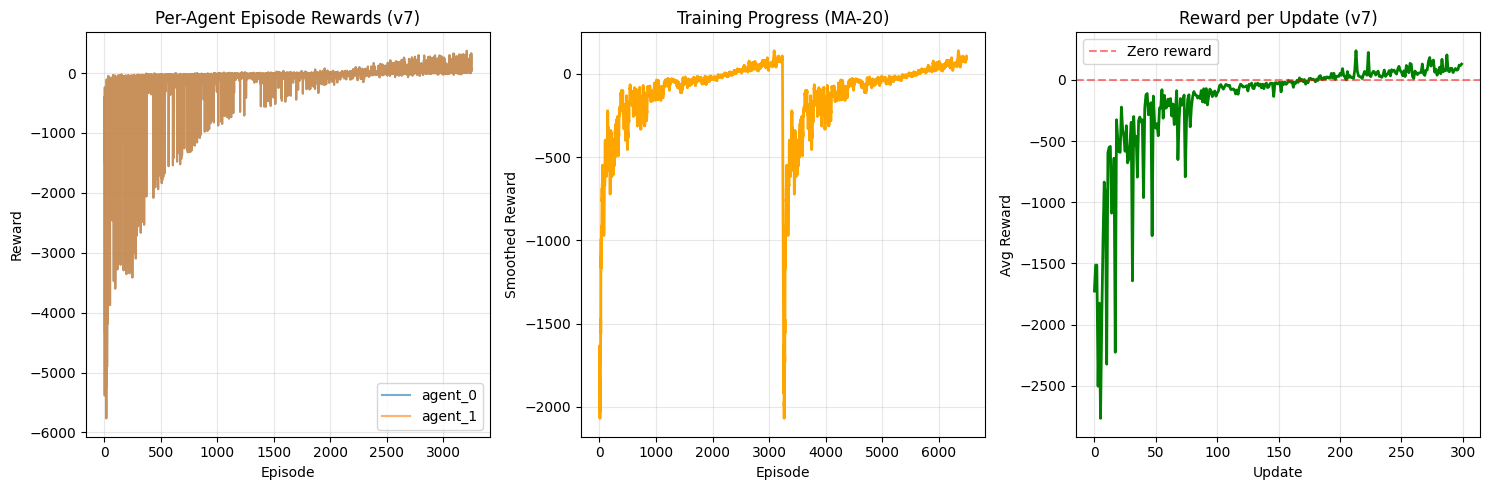


Training Statistics (v7):
agent_0:
  Episodes: 3254
  Mean: -111.6
  Best: 372.5
  Final 10: 104.8
agent_1:
  Episodes: 3254
  Mean: -111.6
  Best: 372.5
  Final 10: 104.8


In [11]:
plt.figure(figsize=(15, 5))

# Plot 1: Per-agent rewards
plt.subplot(1, 3, 1)
for aid in agents:
    if len(episode_rewards[aid]) > 0:
        plt.plot(episode_rewards[aid], alpha=0.6, label=aid)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Per-Agent Episode Rewards (v7)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Smoothed average
plt.subplot(1, 3, 2)
all_rewards = [r for aid in agents for r in episode_rewards[aid]]
if len(all_rewards) >= 20:
    window = 20
    smoothed = np.convolve(all_rewards, np.ones(window)/window, mode='valid')
    plt.plot(smoothed, linewidth=2, color='orange')
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Reward")
    plt.title(f"Training Progress (MA-{window})")
    plt.grid(True, alpha=0.3)

# Plot 3: Update-level rewards
plt.subplot(1, 3, 3)
plt.plot(update_rewards, linewidth=2, color='green')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Zero reward')
plt.xlabel("Update")
plt.ylabel("Avg Reward")
plt.title("Reward per Update (v7)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print(f"\n{'='*70}")
print("Training Statistics (v7):")
print(f"{'='*70}")
for aid in agents:
    if len(episode_rewards[aid]) > 0:
        print(f"{aid}:")
        print(f"  Episodes: {len(episode_rewards[aid])}")
        print(f"  Mean: {np.mean(episode_rewards[aid]):.1f}")
        print(f"  Best: {max(episode_rewards[aid]):.1f}")
        print(f"  Final 10: {np.mean(list(reward_windows[aid])):.1f}")
print(f"{'='*70}")

## Evaluation & Rendering


Evaluation Results (v7) - 1000 steps:
  Average: 881.0


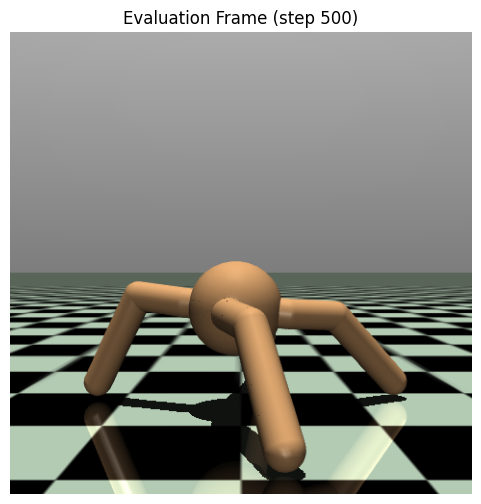

In [12]:
import os
os.environ["MUJOCO_GL"] = "egl"

# Create eval environment
eval_env = mamujoco_v1.parallel_env(
    scenario=config['scenario'],
    agent_conf=config['agent_conf'],
    agent_obsk=config['agent_obsk'],
    render_mode="rgb_array"
)

policy.eval()
obs_dict, _ = eval_env.reset()

frames = []
total_reward_dict = {aid: 0.0 for aid in eval_env.agents}

MAX_STEPS = 1000
for t in range(MAX_STEPS):
    with torch.no_grad():
        mu_dict, std_dict = policy(obs_dict)
        # Use mean action for evaluation
        action_dict = {aid: mu_dict[aid].squeeze(0).cpu().numpy()
                       for aid in eval_env.agents}

    obs_dict, reward_dict, term_dict, trunc_dict, _ = eval_env.step(action_dict)

    for aid in eval_env.agents:
        total_reward_dict[aid] += reward_dict[aid]

    frame = eval_env.render()
    frames.append(frame)

    if any(term_dict.values()) or any(trunc_dict.values()):
        break

eval_env.close()

print(f"\nEvaluation Results (v7) - {t+1} steps:")
for aid in eval_env.agents:
    print(f"  {aid}: {total_reward_dict[aid]:.1f}")
print(f"  Average: {np.mean(list(total_reward_dict.values())):.1f}")

# Display sample frame
if len(frames) > 0:
    plt.figure(figsize=(6, 6))
    plt.imshow(frames[len(frames)//2])
    plt.axis("off")
    plt.title(f"Evaluation Frame (step {len(frames)//2})")
    plt.show()

In [13]:
# Save as GIF
try:
    import imageio
    gif_path = "gnn_ant_v7_enhanced.gif"
    imageio.mimsave(gif_path, frames[::2], fps=20)
    print(f"Saved GIF: {gif_path}")
except:
    print("Install imageio to save GIF: pip install imageio")

Saved GIF: gnn_ant_v7_enhanced.gif
